#### The simplest implementation of Jarzynski + transport with PINN loss

Here we make the jarzynski transport sampler more complicated: sampling an N-D gaussian with potential
$U(t,x)$ arising from a gaussian mixture with time dependent mixture weights $\lambda^i_t$, means $\mu^i(t)$, and covariances $\Sigma^i(t)$ for $i = 1, \dots, N$ mixture components. 

- We will bootstrap up samples of $\rho(x,t)$ using adaptive reweighting and the PINN loss given by:
$$
L_{P I N N}^T[\hat{b}, \hat{F}]=\int_0^T \int_{\mathbb{R}^d}\left|\nabla \cdot \hat{b}_t(x)-\nabla U_t(x) \cdot \hat{b}_t(x)-\partial_t U_t(x)+\partial_t \hat{F}_t\right|^2 \hat{\rho}_t(x) d x d t
$$

Note that this loss can be computed with respect to any $\rho_t$. 


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float)
from dataclasses import dataclass
from typing import Callable, Tuple
from torch.func import vmap

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from scipy.ndimage import gaussian_filter1d ## for plotting smoother loss

import time

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(torch.cuda.is_available())
print(device)

True
cuda


#### Simple utility function to move samples off of gpu

In [3]:
def grab(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return x

#### Define effective sample size to be used later

In [4]:
def ess(At):
    return torch.mean(torch.exp(At))**2 / torch.mean(torch.exp(2*At))

### Define the Gaussian potential function

Can be used to:  
- compute $U(x,t)$
- compute $\rho(x,t)$
- compute $\nabla_x U(x,t)$
- compute $\partial_t U(x,t)$
- sample the associated time dependent density if you want to know the analytic solution in this case

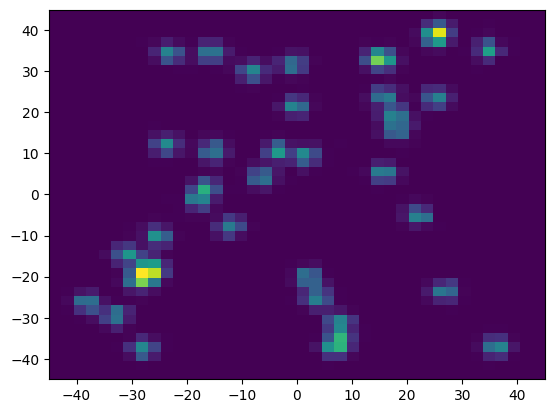

In [5]:
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.func import jacfwd


class GMM(nn.Module):
    def __init__(self, weights_func, means_func, covs_func):
        super(GMM, self).__init__()
        
        self.weights_func = weights_func
        self.means_func   = means_func
        self.covs_func    = covs_func
        
    def setup_params(self, t):
        
        weights = self.weights_func(t)
        means   = self.means_func(t)
        covs = self.covs_func(t)
        return weights, means, covs

    def _single_sample(self, t):
        weights, mus, Cs = self.setup_params(t)
        d = mus.shape[1]
        num_comps = len(weights)
        cat       = dist.Categorical(weights, validate_args=False)
        component = cat.sample((1,))
        mu_i, C_i = mus[component].squeeze(), Cs[component].squeeze()
        z = torch.randn((d), device=mu_i.device)
 
        # cholesky decomp
        L = torch.linalg.cholesky(C_i)

        # transform according to cholesky decomp
        sample = mu_i + z @ L.T
        return sample



    def sample(self, ts):
        # batch it to sample over many ts at once
        samples = vmap(self._single_sample, in_dims=(0), randomness = 'different')(ts)
        return samples
    

    def _single_Ut(self, x, t):
        # single sample U(x) computation
        
        weights, mus, Cs = self.setup_params(t)
        C_inv = torch.linalg.inv(Cs)  # [N, d, d]
        det_C = torch.linalg.det(Cs)  # [N]

        diff = x - mus  # [N, d]
        Us = 0.5 * torch.einsum('nd,nde,ne->n', diff, C_inv, diff)

        mix_Us = torch.log(weights) - Us
        _U = -torch.logsumexp(mix_Us, dim=0)

        return _U
    
    def _single_dtUt(self, x, t):
        # Get parameters at time t, 0, and 1
        weights, mus, Cs = self.setup_params(t)
        weights0, mus0, Cs0 = self.setup_params(0)
        weights1, mus1, Cs1 = self.setup_params(1)

        # Compute derivative of weights w.r.t t
        w_i = weights
        w_i0 = weights0
        w_i1 = weights1
        w_i_prime = w_i1 - w_i0  # w_i'(t)
        w_i_ratio = w_i_prime / w_i  # w_i'(t) / w_i(t)

        # Compute derivative of means w.r.t t
        mu_i = mus
        mu_i0 = mus0
        mu_i1 = mus1
        mu_i_prime = mu_i1 - mu_i0  # mu_i'(t)

        # Compute derivative of covariances w.r.t t
        C_i = Cs
        C_i0 = Cs0
        C_i1 = Cs1
        dC_i_dt = C_i1 - C_i0  # C_i'(t)

        # Compute inverse of covariances
        C_inv = torch.linalg.inv(C_i)

        # Compute differences
        diff = x - mu_i  # [N, d]

        # Compute energy U_i(x, t)
        Us = 0.5 * torch.einsum('nd,nde,ne->n', diff, C_inv, diff)  # [N]

        # Compute S_i and normalization factor
        S_i = torch.log(w_i) - Us
        max_S_i = torch.max(S_i)
        exp_S_i = torch.exp(S_i - max_S_i)
        Z = exp_S_i.sum()
        p_i = exp_S_i / Z  # Probabilities p_i

        # Compute first term of U_i'(t)
        first_term = -torch.einsum('nd,nde,ne->n', mu_i_prime, C_inv, diff)  # [N]

        # Compute second term of U_i'(t)
        temp = torch.einsum('nde,nef,nfg->ndg', C_inv, dC_i_dt, C_inv)  # [N, d, d]
        second_term = -0.5 * torch.einsum('nd,ndg,ng->n', diff, temp, diff)  # [N]

        # Compute U_i'(t)
        U_i_prime = first_term + second_term  # [N]

        # Compute s_i'(t)
        s_i_prime = w_i_ratio - U_i_prime  # [N]

        # Compute derivative of U(x, t) w.r.t t
        dtUt = -torch.sum(p_i * s_i_prime)

        return dtUt
    
    def Ut(self, x, t):
        """Compute the energy U(x) on a batch of samples x using vmap.
        Args:
            x (torch.tensor): Batch of samples [bs, d]

        Returns:
            _type_: _description_
        """
        # Ensure x and t are batched and have the same first dimension
        assert x.shape[0] == t.shape[0], "x and t must have the same batch size"
        batched_U = vmap(self._single_Ut, in_dims=(0, 0), out_dims=0)
        
        return batched_U(x, t)
    
    # could be done with autodiff
    # def _single_dtUt(self, x, t):
    #     return jacfwd(self._single_Ut, 1)(x,t)
    
    def dtUt(self, x, t):
        return vmap(self._single_dtUt, in_dims=(0,0), randomness='different')(x,t)
    
    # could be done with autodiff
    # def _single_dxUt(self, x, t):
    #     return jacfwd(self._single_Ut, 0)(x,t)
    
    def _single_dxUt(self, x, t):
        # Compute gradient of U(x) with respect to x
        with torch.no_grad():
            weights, mus, Cs = self.setup_params(t)
            C_inv = torch.linalg.inv(Cs)  # [N, d, d]
            diff = x - mus  # [N, d]
            Us = 0.5 * torch.einsum('nd, nde, ne -> n', diff, C_inv, diff)
            mix_Us = torch.log(weights) - Us
            log_S = torch.logsumexp(mix_Us, dim=0)  # Scalar
            log_Pis = mix_Us - log_S  # Log probabilities
            Pis = torch.exp(log_Pis)  # [N]
            grads = torch.einsum('nde, ne -> nd', C_inv, diff)  # [N, d]
            dxU = torch.einsum('n, nd -> d', Pis, grads)  # [d]
        return dxU
    
    def dxUt(self, x, t):
        return vmap(self._single_dxUt, in_dims=(0,0), randomness='different')(x,t)

    def Z(self, t):
        weights, mus, Cs = self.setup_params(t)
        d = mus.shape[1]  # Dimensionality of the data
        det_Cs = torch.linalg.det(Cs)  # Determinants of covariance matrices [N]
        sqrt_det_Cs = torch.sqrt(det_Cs)  # Square roots of determinants [N]
        weighted_sqrt_det = weights * sqrt_det_Cs  # Weighted square roots [N]
        sum_weighted_sqrt_det = torch.sum(weighted_sqrt_det)
        Z_t = (2 * torch.pi) ** (d / 2) * sum_weighted_sqrt_det
        return Z_t
    

# example
# torch.manual_seed(8)
# N0, N1 = 1, 8
# d = 3
# lams_0 = torch.ones(N0).to(device) / N0
# lams_1 = torch.ones(N1).to(device) / N1  # Non-uniform weights
# mus_0 = 0.0 * torch.zeros((N0, d)).to(device)     # Initial means at t=0
# mus_1 = 2.0 * torch.randn((N1, d)).to(device)      # Final   means at t=1
# Cs_0 = torch.stack([torch.eye(d) for _ in range(N0)]).to(device)  # Initial covariances
# Cs_1 = 1.0 * torch.stack([torch.eye(d) for _ in range(N1)]).to(device)  # Final covariances

# 40-gmm
torch.manual_seed(8)
N0, N1 = 1, 40
d = 2
lams_0 = torch.ones(N0).to(device)/N0
lams_1 = torch.ones(N1).to(device)/N1
mus_0 = 0.0*torch.zeros((N0, d)).to(device)     # Initial means at t=0
# mus_1 = 4.0*torch.randn((N1, d))      # Final   means at t=1
# mus_1 = 10.0*torch.randn((N1, d)).to(device)      # Final   means at t=1
mus_1 = torch.tensor([
    [ -0.2995,  21.4577],
    [-32.9218, -29.4376],
    [-15.4062,  10.7263],
    [ -0.7925,  31.7156],
    [ -3.5498,  10.5845],
    [-12.0885,  -7.8626],
    [-38.2139, -26.4913],
    [-16.4889,   1.4817],
    [ 15.8134,  24.0009],
    [-27.1176, -17.4185],
    [ 14.5287,  33.2155],
    [ -8.2320,  29.9325],
    [ -6.4473,   4.2326],
    [ 36.2190, -37.1068],
    [-25.1815, -10.1266],
    [-15.5920,  34.5600],
    [-25.9272, -18.4133],
    [-27.9456, -37.4624],
    [-23.3496,  34.3839],
    [ 17.8487,  19.3869],
    [  2.1037, -20.5073],
    [  6.7674, -37.3478],
    [-28.9026, -20.6212],
    [ 25.2375,  23.4529],
    [-17.7398,  -1.4433],
    [ 25.5824,  39.7653],
    [ 15.8753,   5.4037],
    [ 26.8195, -23.5521],
    [  7.4538, -31.0122],
    [-27.7234, -20.6633],
    [ 18.0989,  16.0864],
    [-23.6941,  12.0843],
    [ 21.9589,  -5.0487],
    [  1.5273,   9.2682],
    [ 24.8151,  38.4078],
    [-30.8249, -14.6588],
    [ 15.7204,  33.1420],
    [ 34.8083,  35.2943],
    [  7.9606, -34.7833],
    [  3.6797, -25.0242]
]).to(device)
Cs_0 = 2.0*torch.stack([torch.eye(d) for _ in range(N0)]).to(device)  # Initial covariances
Cs_1 = 1.724*torch.stack([torch.eye(d) for _ in range(N1)]).to(device)  # Initial covariances


t = 1.0
def mus_func(t):
    return (1 - t) * mus_0  + t * mus_1
lams_func = lambda t: (1 - t) * lams_0 + t * lams_1
def lams_func(t):
    return (1 - t) * lams_0  + t * lams_1
def covs_func(t):
    return (1 - t) * Cs_0  + t * Cs_1

# Define the GMM
gmm = GMM(lams_func, mus_func, covs_func)

# Sample from the GMM
bs = 10000
ts = t*torch.ones(bs).to(device)

samples = gmm.sample(ts)

samples = grab(samples)
plt.hist2d(samples[:,0], samples[:,1], bins = 40, range=[[-45,45],[-45,45]]);


### vector $b$ network, whose gradient and time derivative we will use

In [6]:
from torch.func import jacfwd
class VectorField(torch.nn.Module):
    #  nn that takes x in R^d and t in [0, 1] and outputs R^d
    def __init__(self, d, hidden_sizes=(32, 32, 32), activation=torch.nn.SiLU, hutch = False):
        super(VectorField, self).__init__()
        self.d = d
        layers = []
        input_dim = d + 1  # Assuming input dimension is 1; adjust as needed
        for hidden_size in hidden_sizes:
            layers.append(torch.nn.Linear(input_dim, hidden_size))
            layers.append(activation())
            input_dim = hidden_size
        layers.append(torch.nn.Linear(input_dim, d))  # Output layer
        self.net = torch.nn.Sequential(*layers)
        self.hutch = hutch
        
    def ensure_size1(self, tensor):
        
        if tensor.dim() == 0:
            return tensor.unsqueeze(0)
        return tensor

    def _single_forward(self, x, t):
       
        x = self.ensure_size1(x)
        t = self.ensure_size1(t)
        
        xt = torch.concatenate((x,t))
        return self.net(xt).squeeze()

    def forward(self, x, t):
        return vmap(self._single_forward, in_dims=(0,0), out_dims=(0))(x,t)
    
    def _single_divx(self, x, t):
        return torch.diag(jacfwd(self._single_forward, 0)(x,t)).sum()
    
    def _single_divx_hutch(self, x, t):
        h = 0.01
        zeta = torch.randn(x.shape).to(x)
        inp = x + h*zeta
        return h*torch.sum(zeta * self._single_forward(inp,t)) 
       
    def divx(self, x, t):
        if self.hutch:
            return vmap(self._single_divx_hutch, in_dims=(0,0), out_dims=(0), randomness='different')(x,t)
        else:
            return vmap(self._single_divx, in_dims=(0,0), out_dims=(0), randomness='different')(x,t)
    


### Network for $\hat F_t$

In [7]:
from torch.func import jacfwd
class FNetwork(torch.nn.Module):
    # nn that takes x in R^d and t in [0, 1] and outputs a scalar
    def __init__(self, hidden_sizes=(32, 32, 32), activation=torch.nn.SiLU):
        super(FNetwork, self).__init__()
        layers = []
        input_dim = 1  # Assuming input dimension is 1; adjust as needed
        for hidden_size in hidden_sizes:
            layers.append(torch.nn.Linear(input_dim, hidden_size))
            layers.append(activation())
            input_dim = hidden_size
        layers.append(torch.nn.Linear(input_dim, 1))  # Output layer
        self.net = torch.nn.Sequential(*layers)
        
    def ensure_size1(self, tensor):
        
        if tensor.dim() == 0:
            return tensor.unsqueeze(0)
        return tensor

    def _single_forward(self, t):
       
        t = self.ensure_size1(t)
        
        return self.net(t).squeeze()

    def forward(self, t):
        return vmap(self._single_forward, in_dims=(0), out_dims=(0))(t)
    
    def _single_gradt(self, t):
        return jacfwd(self._single_forward, 0)(t)
       
    def gradt(self, t):
        return vmap(self._single_gradt, in_dims=(0), out_dims=(0), randomness='different')(t)
    


### Define Jarzysnki sampler with transport

In [8]:
### resampling code if you want to do resampling

def systematic_resample(weights):
    """Performs the systematic resampling algorithm used by particle filters.
    This algorithm separates the sample space into N divisions. A single random
    offset is used to choose where to sample from for all divisions. This
    guarantees that every sample is exactly 1/N apart.

    Parameters
    ----------
    weights : torch.Tensor
        Tensor of weights as floats
    Returns
    -------
    indexes : torch.Tensor
        Tensor of indexes into the weights defining the resample. i.e. the
        index of the zeroth resample is indexes[0], etc.
    """
    N = len(weights)

    # Make N subdivisions, and choose positions with a consistent random offset
    # positions = (torch.rand(1) + torch.arange(N)) / N
    positions = (torch.arange(N, device=weights.device) + torch.rand(1, device=weights.device)) / N

    # Initialize indexes array
    indexes = torch.zeros(N, dtype=torch.int64)

    # Calculate the cumulative sum of weights
    cumulative_sum = torch.cumsum(weights, dim=0)

    # Initialize pointers
    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1

    return indexes


def stratified_resample(weights):
    """Performs the stratified resampling algorithm used by particle filters.
    This algorithm separates the sample space into N divisions and ensures at least
    one sample is chosen from each division.

    Parameters
    ----------
    weights : torch.Tensor
        Tensor of weights as floats
    Returns
    -------
    indexes : torch.Tensor
        Tensor of indexes into the weights defining the resample. i.e. the
        index of the zeroth resample is indexes[0], etc.
    """
    N = len(weights)

    # Create an array of equally spaced intervals with a random offset in each
    positions = (torch.arange(N, dtype=torch.float32) + torch.rand(N)) / N

    # Initialize indexes array
    indexes = torch.zeros(N, dtype=torch.int64)

    # Calculate the cumulative sum of weights
    cumulative_sum = torch.cumsum(weights, dim=0)

    # Initialize pointers
    i, j = 0, 0
    while i < N:
        if positions[i] < cumulative_sum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1

    return indexes

def multinomial_resample(weights):
    """Performs multinomial resampling.
    Parameters
    ----------
    weights : torch.Tensor
        Tensor of weights as floats
    Returns
    -------
    indexes : torch.Tensor
        Tensor of indexes into the weights defining the resample.
    """
    N = len(weights)
    indexes = torch.multinomial(weights, num_samples=N, replacement=True)
    return indexes


In [9]:
@dataclass
class JarzynskiIntegrator:
    b: VectorField
    gmm: GMM
    eps: torch.tensor
    ts:     torch.tensor
    transport: bool = True
    n_save: int  = 10 ## will save n_save + the initial state
    device: str = device
    resample: bool = False
    resample_thres: float = 0.7

    def __post_init__(self) -> None:
        """Initialize time grid and step size."""
        
        # self.ts = torch.linspace(0, self.t_max, self.n_step + 1).to(self.device)
        # self.dt = (self.ts[1] - self.ts[0]).to(self.device)
        self.n_step = len(self.ts) - 1 ## -1 because 0 is the first element of self.ts
        
        assert self.n_save > 0 ## will always save the first sample
        assert self.n_step % self.n_save == 0, f"{self.n_step} is not divisible by {self.n_save}"
        self.save_freq = self.n_step // self.n_save
        
    def ess(self, At):
        return torch.mean(torch.exp(At))**2 / torch.mean(torch.exp(2*At))

    def _single_step_x(self, x,t, dt):
        """
        Performs the update
        x_{t+1} = x - \epsilon*\nabla_x U_t*dt + b(t,x)*dt + \sqrt{2*\epsilon}*dW_t   ### Note switched to + btx 
        """
        if self.transport:
            btx = self.b(x.unsqueeze(0),t.unsqueeze(0)).squeeze()
            r1 = torch.randn(size=x.shape).to(self.device).squeeze()
            dW = torch.sqrt(dt)*r1
            dxU = self.gmm._single_dxUt(x,t).squeeze()
            return x - self.eps*dxU*dt + btx*dt + torch.sqrt(2*self.eps)*dW, r1
        else:
            r1 = torch.randn(size=x.shape).to(self.device).squeeze()
            dW = torch.sqrt(dt)*r1
            dxU = self.gmm._single_dxUt(x,t).squeeze()
            return x - self.eps*dxU*dt + torch.sqrt(2*self.eps)*dW, r1
        
    def step_x(self, x, t, dt):
        return vmap(self._single_step_x, in_dims=(0,0,0), out_dims=(0), randomness='different')(x,t, dt)
    
    def _single_step_A(self, x,t, A, r1, dt):
        """
        Performs the update
        B_{t+1} = B_{t} - \partial_t U_t*dt + (\frac{1}{\epsilon})*\partial_t \phi_t*dt 
                        - (\frac{1}{\epsilon})*|\nabla_x \phi|^2*dt + \sqrt{\frac{2}{\epsilon}*dt}*\nabla_x \phi \cdot z
        where z \sim N(0,1)
        """
        x = x
        
        if self.transport:
            # dtphi_val = self.phi._single_gradt(x,t).squeeze()   ## shape []
            x = x.unsqueeze(0)
            t = t.unsqueeze(0)
            btx       = self.b(x,t).squeeze()             ## shape [d]
            dtU       = self.gmm._single_dtUt(x,t).squeeze()     ## shape []
            dxU       = self.gmm._single_dxUt(x,t).squeeze()     ## shape []
            
            dxphi_dot_noise = torch.sum(btx*r1.squeeze(), dim=-1)#.squeeze() ## sum over d
            div_btx = self.b.divx(x,t).squeeze() ## sum over d
            
            return (A - dtU*dt - torch.sum(btx*dxU)*dt + div_btx*dt)

        else:
            dtU       = self.gmm._single_dtUt(x,t)
            return    (A - dtU*dt)
        
    def step_A(self, x, t, A, r1, dt):
        return vmap(self._single_step_A, in_dims=(0,0,0,0,0), out_dims=(0), randomness='different')(x,t,A,r1,dt)

    
   
    def rollout(self, x_init):
        """
        Performs the rollout
        """
        bs = x_init.shape[0]
        xs = torch.zeros((self.n_save +1, *x_init.shape)).to(device)
        As = torch.zeros((self.n_save +1, bs)).to(device)

        # initialize weights A to zero
        A = torch.zeros(bs).to(self.device)
        x = x_init
        
        xs[0] = x_init
        As[0] = A
        
        save_ind = 1
        resample_count = 0
        for i, t in enumerate(self.ts[:-1]):
            dt = (self.ts[i+1] - self.ts[i]).repeat(len(x)) ### assumes first element in self.ts is 0
            t = t.repeat(len(x)).requires_grad_(True)
            x_new, r1 = self.step_x(x.requires_grad_(True), t, dt)
            A_new = self.step_A(x, t, A, r1, dt)
            t_new = self.ts[i+1].repeat(len(x)).requires_grad_(True)

            
            if self.ess(A_new) < self.resample_thres and self.resample:
                resample_count +=1
                print("i:", i, "resample cout:", resample_count)
                weights = torch.softmax(A_new, dim = 0)
                indices = systematic_resample(weights)
                x_new   = torch.clone(x_new[indices])
                A_new   = torch.zeros(len(weights)).to(device)
                
            if (i + 1) % self.save_freq == 0:            
                xs[save_ind] = torch.clone(x_new.detach())
                As[save_ind] = torch.clone(A_new.detach())
                save_ind += 1

            x = x_new.detach()
            A = A_new.detach()
            del x_new, r1, t, A_new

        # ensure the last state is saved
        # print(A)
        xs[-1] = x.detach()
        As[-1] = A.detach()

        return xs, As



### Define loss function

In [10]:
def loss_function(b, F, gmm, x, t, pts, nt, tf, tmin):
    """PINN LOSS
       notes TODO 
    Returns:
        torch.tensor: loss value 
    """

    x.requires_grad_(True)
    t.requires_grad_(True)

    assert x.shape[0] == len(t)

    
    # b div b
    btx     = b(x,t)
    div_btx = b.divx(x,t)
    
    # div U 
    dxUt  = gmm.dxUt(x,t)
    dtUt  = gmm.dtUt(x,t)
    
    # partial_t F
    dtF     = F.gradt(t)
    
    term1 = pts*(div_btx - torch.sum(btx*dxUt, dim=-1) - dtUt + dtF )**2
    # term1 = pts*(div_btx - torch.sum(btx*dxUt, dim=-1) - dtUt )**2
    term1 = (tf-tmin)*term1.view(nt,-1).sum(-1).mean()
    
    loss = term1

    return loss



### Set up network and train step

In [11]:
def repeat_integers(start, end, n_opt):
    """
    Use this function to make a list of length n_opt that anneals how many sampling steps are taken
    """
    range_length = end - start + 1
    full_repeats, remainder = divmod(n_opt, range_length)
    
    result = []
    for i in range(start, end + 1):
        result.extend([i] * full_repeats)
    
    if remainder > 0:
        result.extend([end] * remainder)
    
    return result


In [12]:
lr     = 2e-3
n_opt  = 1000
hutch  = False

# torch.manual_seed(1)
l = 300
b       = VectorField(d, hidden_sizes=(l,l,l,l), hutch = hutch).to(device)
F       = FNetwork(hidden_sizes=(l,l,l)).to(device)
params = list(b.parameters()) + list(F.parameters())
# params = list(b.parameters())
opt     = torch.optim.Adam( params, lr=lr)
sched   = torch.optim.lr_scheduler.StepLR(optimizer=  opt, step_size=100, gamma=0.94)


In [13]:
delta_t = 0.01
bs      = 300
k_max       = int(1/delta_t)
print("K max:", k_max)

### this specifies how to do the annealing if start=1/delta_t, then we are always learning on the whole time interval
### if start = 1, then we initially learn the first time interval, e.g. over [0, 0.01] and anneal to [0, 1] by the end of n_opt
start = 100
end = k_max
ks = repeat_integers(start, end, n_opt)
# print(ks)
metrics_freq = 50
resample = False

_ess = 0.0

K max: 100


In [14]:

def train_step(b, F, gmm, opt, sched, bs = 10, k=1, delta_t = 0.05, eps = 1.0, resample=False):
    
    opt.zero_grad()
    
    ### LATER set 1.0 to be some tf
    final_t = k*delta_t
    t_set = final_t*torch.rand(k - 1) # -1 because we append 1.0 at the end
    t_set = torch.cat((torch.tensor([0.0]), t_set, torch.tensor([final_t])))
    # Sort the numbers to get randomly spaced samples
    ts = torch.sort(t_set).values.to(device)

    jit = JarzynskiIntegrator(b, gmm, eps = eps, ts = ts,
                              transport=True, n_save = k, device=device, resample=resample, resample_thres=0.5)
    
    
    t0           = torch.zeros(bs).to(device)
    x0s          = gmm.sample(t0).to(device)
    xs, As       = jit.rollout(x0s)
    d = xs.shape[-1]
    
    tmin    = ts[0]
    tf      = ts[-1]
    
    # K = 15
    # indices = torch.randperm(ts.shape[0])#[:K]
    # ts      = ts[indices]
    ts      = ts.repeat_interleave(bs) 
    nt      = xs.shape[0]  
    xs      = xs[:].detach() 
    # xs      = xs[indices]
    xs      = xs.view(-1, d).detach()
    
    pts     = torch.softmax(As, dim=1)
    # pts     = (1/bs)*torch.ones(bs).repeat(nt, 1).to(device) #### turning off the weights as a test

    # pts     = pts[indices]
    pts     = pts.view(-1) 
    pts     = pts.flatten()
    

    # nt = K
    # pinn loss
    loss_val     = loss_function(b, F, gmm, xs, ts, pts, nt, tf, tmin)

    loss_val.backward()
    opt.step()
    sched.step()
    
    return grab(loss_val)

    

### Do the training

In [15]:

losses = []
esses  = []
from IPython.display import clear_output

In [16]:
bs = 400

In [17]:
# torch.manual_seed(1)
pbar = tqdm(range(len(losses), 10*n_opt))
# pbar = tqdm(range(n_opt))



for i in pbar:
    # eps = ((5.0 - 0.1)*torch.rand(1) + 0.1).squeeze().to(device)
    eps = 4.0*torch.tensor(1.0).squeeze()
    if i >= len(ks):
        k = ks[-1]
    else:
        k = ks[i]
    loss = train_step(b, F, gmm, opt, sched, bs = bs,
                      k = int(k), delta_t = delta_t, eps = eps, resample=resample)
    losses.append(loss)
    pbar.set_description(f'Loss: {loss:.4f} Ess: {grab(_ess):.4f}')
    
    sigma = 2  # standard dev for Gaussian kernel
    losses_sm = gaussian_filter1d(losses, sigma)

    if i % metrics_freq == 0:
        eps = torch.tensor(1.0).to(device)
        t_final = k*delta_t
        ts = torch.linspace(0, t_final, k + 1).to(device)
        jit = JarzynskiIntegrator(b, gmm, eps = eps, ts = ts,
                                  transport=True,  n_save = int(k))
        bs_samp = 2000
        t0           = torch.zeros(bs_samp).to(device)
        x_init       = gmm.sample(t0).to(device)
        xs, As = jit.rollout(x_init)
        A1 = As[-1]
        _ess = ess(A1)
        esses.append(_ess.detach().cpu().numpy())
    # clear_output(wait=True)

  0%|          | 0/10000 [00:00<?, ?it/s]

ESS: tensor(0.9787, device='cuda:0', dtype=torch.float64)


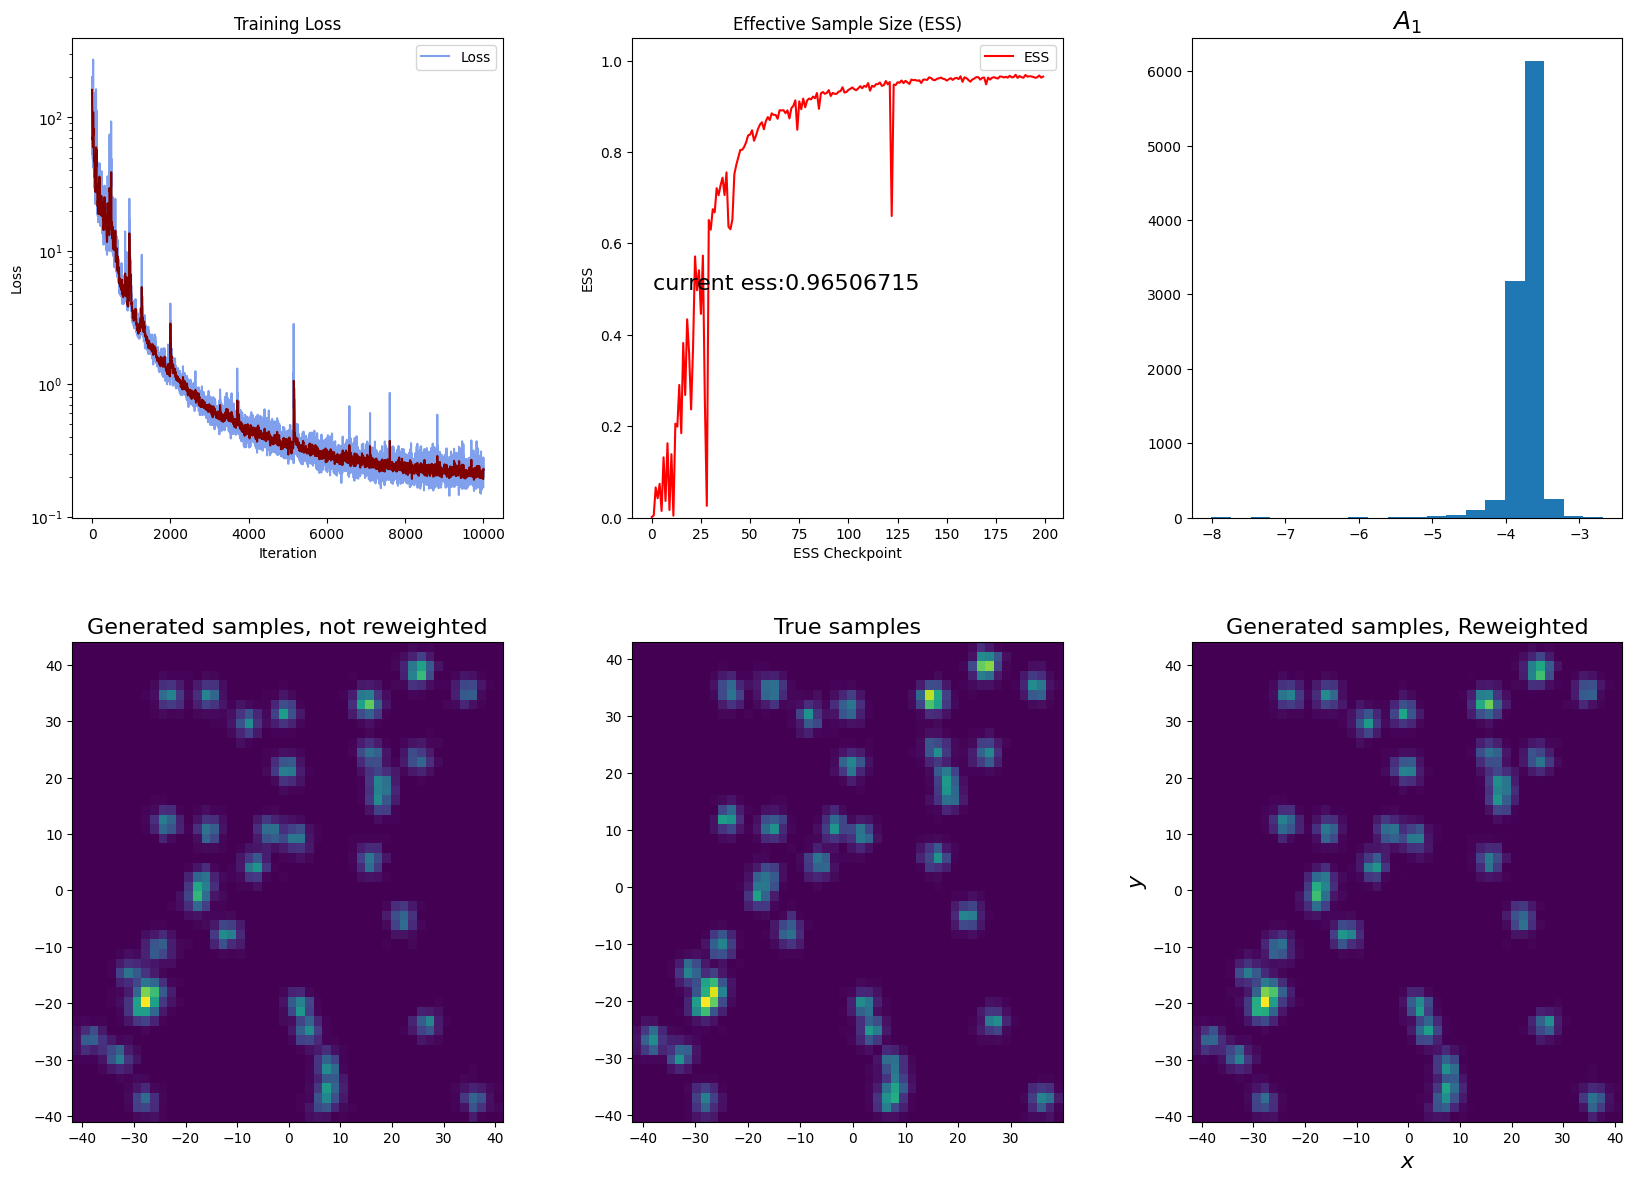

In [18]:
eps = torch.tensor(4.0).to(device)
t = 1.0
ts = torch.linspace(0, t, 150 + 1).to(device)
jit = JarzynskiIntegrator(b, gmm,eps = eps, ts = ts, 
                          transport=True, n_save = 2, resample=False)
torch.manual_seed(0)
bs_samp = 10000
t0           = torch.zeros(bs_samp).to(device)
x_init       = gmm.sample(t0).to(device)
xs,  As = jit.rollout(x_init)
A1 = As[-1].double()
_ess = ess(A1)
print("ESS:", _ess)
cmax = 0.1


from matplotlib import gridspec

# Set up the initial figure and axes
fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(5, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1, 1, 1], wspace=0.3, hspace=0.7)

# Create subplots
ax_loss = fig.add_subplot(gs[:2, 0])
ax_ess = fig.add_subplot(gs[:2,  1])
ax_expA = fig.add_subplot(gs[:2, 2])
ax_hist1 = fig.add_subplot(gs[2:4, 0])
ax_hist2 = fig.add_subplot(gs[2:4, 1])
ax_hist3 = fig.add_subplot(gs[2:4, 2])





sigma = 2  # standard dev for Gaussian kernel
losses_sm = gaussian_filter1d(losses, sigma)
ax_loss.plot(losses, label='Loss', color='xkcd:blue', alpha = 0.5)
ax_loss.plot(losses_sm , color='maroon', alpha=1.0)
ax_loss.set_title('Training Loss')
ax_loss.set_xlabel('Iteration')
ax_loss.set_ylabel('Loss')
ax_loss.set_yscale('log')
ax_loss.legend(loc='upper right')

ax_ess.plot(esses, label='ESS', color='red')
ax_ess.set_title('Effective Sample Size (ESS)')
ax_ess.set_xlabel('ESS Checkpoint')
ax_ess.set_ylabel('ESS')
ax_ess.text(x = 0.5, y = 0.5, s= "current ess:" + str(esses[-1]), fontsize = 16)
ax_ess.set_ylim(0,1.05)
ax_ess.legend(loc='best')


bins = 50
xs_full = grab(xs[-1])
As_full = grab(As[-1])
ax_hist1.hist2d(xs_full[:,0], xs_full[:,1], bins=bins, cmax = cmax, density = True)
ax_hist1.set_title("Generated samples, not reweighted", fontsize=16)

bs_samp = int(1e4)
t1      = t*torch.ones(bs_samp).to(device)
samples = gmm.sample(t1)
ax_hist2.hist2d(grab(samples)[:,0], grab(samples)[:,1], bins=bins, cmax = cmax, density = True)
ax_hist2.set_title("True samples", fontsize=16)

weights = np.exp(As_full)
weights /= weights.sum()
n1 = len(As_full)
kk = np.random.choice(n1, size=n1, replace=True, p=grab(weights))
Xw = grab(xs_full[kk])
ax_hist3.hist2d(xs_full[:, 0], xs_full[:, 1], bins=bins, 
                weights=weights, density=True, label='$X_1$ reweighted', cmax = cmax)
ax_hist3.set_xlabel('x', fontsize=16, fontstyle='italic')
ax_hist3.set_ylabel('y', fontsize=16, fontstyle='italic')
ax_hist3.set_title("Generated samples, Reweighted", fontsize=16)

   
ax_expA.hist(grab(As[-1]), bins = 20)
ax_expA.set_title(r"$A_1$", fontsize = 18)


plt.show()



In [19]:
x

NameError: name 'x' is not defined

### Make scaling plot

In [20]:
epses = [0.0, 4.0, 6.0, 10.0, 20.0, 40.0, 80.0]
epses = [torch.tensor(eps).to(device) for eps in epses]
steps = [200, 200, 400, 600,  800,  1000, 2000]


esses_transp   = []
esses_notransp = []

for (i, vals) in enumerate(zip(epses,steps)):
    print(vals)
    eps, n_step = torch.tensor(vals[0]), vals[1]
    ts = torch.linspace(0, 1, n_step + 1).to(device)
    jit_transp   = JarzynskiIntegrator(b, gmm, eps = eps, ts = ts, 
                          transport=True, n_save = 4, resample=False)
    jit_notransp = JarzynskiIntegrator(b, gmm, eps = eps, ts = ts, 
                          transport=False, n_save = 4, resample=False)
    
    bs_samp = 2000
    t0           = torch.zeros(bs_samp).to(device)
    x_init       = gmm.sample(t0).to(device)
    xs, As = jit_transp.rollout(x_init)
    A1 = As[-1]
    ess_transp = ess(A1)
    esses_transp.append(ess_transp)
    
    xs, As = jit_notransp.rollout(x_init)
    A1 = As[-1]
    ess_notransp = ess(A1)
    esses_notransp.append(ess_notransp)
    print(ess_transp, ess_notransp)


(tensor(0., device='cuda:0'), 200)


/tmp/ipykernel_4057405/452694504.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  eps, n_step = torch.tensor(vals[0]), vals[1]


tensor(0.9580, device='cuda:0') tensor(0.0026, device='cuda:0')
(tensor(4., device='cuda:0'), 200)
tensor(0.9797, device='cuda:0') tensor(0.0026, device='cuda:0')
(tensor(6., device='cuda:0'), 400)
tensor(0.9842, device='cuda:0') tensor(0.0189, device='cuda:0')
(tensor(10., device='cuda:0'), 600)
tensor(0.9796, device='cuda:0') tensor(0.0097, device='cuda:0')
(tensor(20., device='cuda:0'), 800)
tensor(0.9930, device='cuda:0') tensor(0.0059, device='cuda:0')
(tensor(40., device='cuda:0'), 1000)
tensor(0.9961, device='cuda:0') tensor(0.0020, device='cuda:0')
(tensor(80., device='cuda:0'), 2000)
tensor(0.9979, device='cuda:0') tensor(0.0097, device='cuda:0')


(-0.05, 1.02)

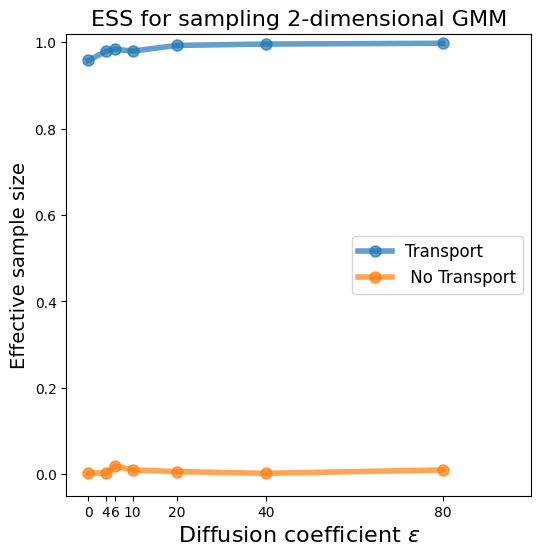

In [21]:
fig = plt.figure(figsize=(6,6))

eps_list = np.array([grab(eps) for eps in epses])


esses_transp = [grab(ess) for ess in esses_transp]
esses_notransp = [grab(ess) for ess in esses_notransp]
plt.plot(eps_list, grab(esses_transp), linewidth = 4, alpha = 0.7, marker = 'o', markersize=8, label='Transport')
plt.plot(eps_list, grab(esses_notransp), linewidth = 4, alpha = 0.7, marker = 'o', markersize=8, label=' No Transport')
plt.ylabel("Effective sample size", fontsize = 14)
plt.xlabel("Diffusion coefficient $\epsilon$", fontsize = 16)
plt.title("ESS for sampling "+ str(d) + "-dimensional GMM", fontsize = 16)
plt.legend(fontsize=12, loc = 'center right')
# plt.yscale('log')
# plt.xscale('log')
plt.xticks(eps_list);
plt.xlim(-5.0, 100)
plt.ylim(-0.05, 1.02)

In [ ]:
# torch.save(b, "models/2d-40gmm-pinn-b-no-F-in-loss.pt")
# torch.save(gmm, "models/2d-40gmm--no-F-in-loss.pt")
# # torch.save(F, "models/2d-40gmm-v2-pinn-F-v2.pt")